# 04 ST-GCN training recipe

**Question.** Can a better training recipe close the gap to Li et al. (2024) on top 1 accuracy and reduce the
24 point train to test gap seen in the normalisation experiment?

**Protocol.** Everything here is decided on the **validation set only**. The test set is not evaluated in any
run in this notebook (the runs train and report on `train` and `val`). Tuning seeds (11, 22) differ from the
seeds used for the final results (42, 123, 7), so a configuration cannot be selected for suiting a final seed.

**Fixed.** ST-GCN with the paper configuration, `body_court` input (chosen in notebook 03), repaired keypoints,
advanced augmentation, momentum 0.9, batch 16, up to 60 epochs with patience 20, checkpoint chosen on
validation top 1.

**Baseline.** The recipe from notebook 03: weight decay 1e-3, no label smoothing, StepLR (step 10), 500 clips
per class per epoch.

**Stage A: one change at a time.** Each factor is applied to the baseline alone.

| factor | change | why |
|---|---|---|
| label smoothing | 0.1 | helped alone in an earlier single seed ablation, never combined with weight decay |
| weight decay | 5e-3 | 1e-3 was the strongest single regulariser; the train/test gap suggests room for more |
| schedule | lr 0.01 until epoch 25, 1e-3 until 40, 1e-4 after | StepLR is at 1e-4 by epoch 20, so late epochs barely train |
| sampler | 300 clips per class instead of 500 | fewer repeated copies of rare classes per epoch |

**Stage B: combination.** Every factor that helps is combined into one configuration and run on the same seeds.

**Selection rule (fixed before running).**
1. A factor counts as helping if its mean validation top 1 is at least 0.5 points above the baseline and its
   mean validation MCA is not more than 1 point below the baseline.
2. The final recipe is the configuration with the highest mean validation top 1 among the baseline, the helping
   single factors and the combination. If two are within 0.3 points, the one with fewer changes from the
   baseline wins.

With two seeds and a validation set of 781 clips, differences under about 1 point are not reliable. The
rule stops the recipe from drifting on noise: nothing changes unless the gain clears 0.5 points.

Runs log to `BadmintonPoseAnalysis/experiments/stgcn_recipe`.

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from clearml import Task

REPO = os.environ.get("BADMINTON_REPO", "/workspace/badminton-honours-project")
DATA = os.environ.get("BADMINTON_DATA", "/workspace/data")
sys.path.insert(0, REPO)
import dataset as ds
import training as tr
from models import stgcn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__, device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})

2.1.0+cu118 cuda NVIDIA GeForce RTX 4090


In [2]:
PROJECT = "BadmintonPoseAnalysis/experiments/stgcn_recipe"
KEYPOINTS = f"{DATA}/keypoints_interp"
OUT = os.environ.get("BADMINTON_OUTPUTS", "/workspace/outputs") + "/experiments/stgcn_recipe"
os.makedirs(OUT, exist_ok=True)

SEEDS = [11, 22]
SPLITS = ("train", "val")          # the test set is never evaluated while tuning
NORMALISATION, USE_COURT = "body", True
NUM_WORKERS = 12

FIXED = {"model": "ST-GCN", "augmentation": "advanced", "min_native_frames": 5, "batch_size": 16, "lr": 0.01,
         "momentum": 0.9, "gamma": 0.1, "num_epochs": 60, "patience": 20, "select_metric": "top1",
         "normalisation": "body_court"}
BASELINE = {"weight_decay": 1e-3, "label_smoothing": 0.0, "schedule": "step10", "target_per_class": 500}
FACTORS = {
    "label_smoothing_0.1": {"label_smoothing": 0.1},
    "weight_decay_5e-3": {"weight_decay": 5e-3},
    "schedule_25_40": {"schedule": "multistep_25_40"},
    "sampler_300": {"target_per_class": 300},
}
MIN_GAIN, MAX_MCA_DROP, TIE = 0.005, 0.01, 0.003


def make_scheduler(optimizer, schedule):
    if schedule == "step10":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=FIXED["gamma"])
    if schedule == "multistep_25_40":
        return torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[25, 40], gamma=FIXED["gamma"])
    raise ValueError(schedule)

In [3]:
manifest = ds.load_filtered_manifest(f"{DATA}/split_manifest.csv", f"{DATA}/extraction_log.csv",
                                     f"{DATA}/keypoints_interp_log.csv", FIXED["min_native_frames"])
class_names = sorted(manifest["class_name"].unique())
class_to_id = {c: i for i, c in enumerate(class_names)}
split_hash = open(f"{DATA}/split_manifest.sha256").read().split()[0]
forward = stgcn.make_forward(USE_COURT)
in_channels = 7 if USE_COURT else 5

manual review: dropped 4 clips
short clip rule: dropped 4 train clips with fewer than 5 real frames
7810 clips remain (train 6247, test 782, val 781)


## Run function

One function trains a configuration for one seed and reports it. Finished runs are recorded in `results.csv`
and skipped on re-run, so the notebook can be restarted after an interruption.

In [4]:
results_path = f"{OUT}/results.csv"


def load_results():
    return pd.read_csv(results_path) if os.path.exists(results_path) else pd.DataFrame(columns=["config", "seed"])


def run_config(name, overrides, seed):
    done = load_results()
    if ((done["config"] == name) & (done["seed"] == seed)).any():
        print(f"skip {name} seed {seed}, already done")
        return
    cfg = {**BASELINE, **overrides}
    run_name = f"stgcn_{name}_s{seed}"
    print(f"\n=== {run_name}  {overrides or 'baseline'} ===")
    tr.seed_everything(seed)

    task = Task.init(project_name=PROJECT, task_name=run_name, task_type=Task.TaskTypes.training,
                     tags=["recipe", name, "stgcn", f"seed{seed}"], reuse_last_task_id=False,
                     auto_connect_frameworks={"matplotlib": False, "pytorch": False})
    task.connect({**FIXED, **cfg, "config": name, "changes": overrides, "seed": seed,
                  "keypoints": KEYPOINTS, "split_sha256": split_hash, "evaluated_splits": list(SPLITS)})

    loaders = tr.build_loaders(manifest, KEYPOINTS, class_to_id, FIXED["augmentation"], NORMALISATION, seed=seed,
                               batch_size=FIXED["batch_size"], target_per_class=cfg["target_per_class"],
                               num_workers=NUM_WORKERS)
    model = stgcn.build_stgcn(in_channels, len(class_names)).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=FIXED["lr"], momentum=FIXED["momentum"],
                                weight_decay=cfg["weight_decay"])
    scheduler = make_scheduler(optimizer, cfg["schedule"])
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg["label_smoothing"])

    _, history, best_epoch = tr.train_model(model, forward, loaders, optimizer, scheduler, criterion, device,
                                            task.get_logger(), num_epochs=FIXED["num_epochs"],
                                            patience=FIXED["patience"], select_metric=FIXED["select_metric"],
                                            splits=SPLITS)
    metrics = tr.report_run(task, model, forward, loaders, class_names, device, history, best_epoch,
                            out_dir=f"{OUT}/{run_name}", run_name=run_name, splits=SPLITS, show=False,
                            extra={"config": name, "seed": seed})
    task.close()

    pd.concat([done, pd.DataFrame([metrics])], ignore_index=True).to_csv(results_path, index=False)
    del model, loaders
    torch.cuda.empty_cache()

## Smoke test

Run this cell on its own first: one batch through the model with the label smoothing loss, gradient check on
every parameter, both schedulers stepped, and a check that the loaders and reporting never touch the test set.

In [5]:
tr.seed_everything(0)
loaders = tr.build_loaders(manifest, KEYPOINTS, class_to_id, FIXED["augmentation"], NORMALISATION, seed=0,
                           batch_size=FIXED["batch_size"], target_per_class=300, num_workers=2, eval_workers=2)
model = stgcn.build_stgcn(in_channels, len(class_names)).to(device)
batch = next(iter(loaders["train"]))
logits = forward(model, batch, device)
assert logits.shape == (FIXED["batch_size"], len(class_names))
nn.CrossEntropyLoss(label_smoothing=0.1)(logits, batch["label"].to(device)).backward()
assert not [n for n, p in model.named_parameters() if p.requires_grad and p.grad is None]

for schedule in ["step10", "multistep_25_40"]:
    opt = torch.optim.SGD(model.parameters(), lr=FIXED["lr"], momentum=0.9)
    sched = make_scheduler(opt, schedule)
    lrs = []
    for epoch in range(45):
        lrs.append(opt.param_groups[0]["lr"])
        sched.step()
    print(f"{schedule:16s} lr at epochs 0/10/25/40: " + ", ".join(f"{lrs[e]:.0e}" for e in (0, 10, 25, 40)))

before = tr.evaluate(model, loaders["val"], forward, device)
print(f"untrained val top1 {before['top1']:.3f}, {len(loaders['train'].sampler)} training draws per epoch at 300 per class")
del model, loaders
print("smoke test passed")

step10           lr at epochs 0/10/25/40: 1e-02, 1e-03, 1e-04, 1e-06
multistep_25_40  lr at epochs 0/10/25/40: 1e-02, 1e-02, 1e-03, 1e-04


/workspace/venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


untrained val top1 0.014, 7948 training draws per epoch at 300 per class
smoke test passed


## Stage A: baseline and single factors

Five configurations on two seeds: ten runs.

In [6]:
configs_a = {"baseline": {}, **FACTORS}
for name, overrides in configs_a.items():
    for seed in SEEDS:
        run_config(name, overrides, seed)


=== stgcn_baseline_s11  baseline ===
ClearML Task: created new task id=3dedfde622794646a5eeba04006f1186
2026-09-29 07:09:06,247 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/bc2f07e4bf3a48b4b23ebedd69edfb1c/tasks/3dedfde622794646a5eeba04006f1186/output/log
epoch   0  loss 1.927  train 0.595  val 0.609 (mca 0.551)  *
epoch   1  loss 1.417  train 0.664  val 0.634 (mca 0.544)  *
epoch   3  loss 1.082  train 0.714  val 0.654 (mca 0.583)  *
epoch   4  loss 0.993  train 0.752  val 0.657 (mca 0.582)  *
epoch   5  loss 0.909  train 0.749  val 0.668 (mca 0.592)  *
epoch   7  loss 0.770  train 0.787  val 0.690 (mca 0.582)  *
epoch  10  loss 0.440  train 0.893  val 0.738 (mca 0.660)  *
epoch  15  loss 0.252  train 0.948  val 0.727 (mca 0.652)
epoch  20  loss 0.159  train 0.986  val 0.734 (mca 0.647)
epoch  25  loss 0.135  train 0.991  val 0.729 (mca 0.645)
epoch  30  loss 0.113  train 0.994  val 0.732 (mc

███████████████████████████████ 100% | 11.66/11.66 MB [00:02<00:00,  5.68MB/s]: 



=== stgcn_baseline_s22  baseline ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=353631b032d644d2ae2be14bd21dbc95
ClearML results page: https://app.clear.ml/projects/bc2f07e4bf3a48b4b23ebedd69edfb1c/tasks/353631b032d644d2ae2be14bd21dbc95/output/log
epoch   0  loss 1.975  train 0.575  val 0.569 (mca 0.483)  *
epoch   2  loss 1.227  train 0.622  val 0.593 (mca 0.582)  *
epoch   3  loss 1.100  train 0.708  val 0.671 (mca 0.598)  *
epoch   5  loss 0.910  train 0.725  val 0.640 (mca 0.600)
epoch   6  loss 0.839  train 0.764  val 0.704 (mca 0.635)  *
epoch  10  loss 0.447  train 0.888  val 0.729 (mca 0.650)  *
epoch  11  loss 0.360  train 0.911  val 0.741 (mca 0.660)  *
epoch  15  loss 0.256  train 0.946  val 0.720 (mca 0.636)
epoch  20  loss 0.156  train 0.982  val 0.723 (mca 0.632)
epoch  25  loss 0.132  train 0.988  val 0.722 (mca 0.633)
epoch  30  loss 0.121  train 0.990  val 0.722 (mca 0.631)
early stop at epoch 31, best val top1 0.7414 at epoch 11
train top1 0.9105 mca 0.9342 | val top1 0.7414 mca 0.6600


...

███████████████████████████████ 100% | 11.66/11.66 MB [00:02<00:00,  4.85MB/s]: 



=== stgcn_sampler_300_s22  {'target_per_class': 300} ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=4fc0416ebfbf4c12968777618960df3b
ClearML results page: https://app.clear.ml/projects/bc2f07e4bf3a48b4b23ebedd69edfb1c/tasks/4fc0416ebfbf4c12968777618960df3b/output/log
epoch   0  loss 2.001  train 0.588  val 0.588 (mca 0.424)  *
epoch   1  loss 1.472  train 0.649  val 0.621 (mca 0.534)  *
epoch   2  loss 1.276  train 0.650  val 0.634 (mca 0.575)  *
epoch   3  loss 1.169  train 0.697  val 0.673 (mca 0.589)  *
epoch   5  loss 1.012  train 0.725  val 0.676 (mca 0.591)  *
epoch   6  loss 0.928  train 0.775  val 0.699 (mca 0.605)  *
epoch   7  loss 0.890  train 0.766  val 0.704 (mca 0.598)  *
epoch   8  loss 0.842  train 0.781  val 0.707 (mca 0.619)  *
epoch  10  loss 0.581  train 0.847  val 0.738 (mca 0.658)  *
epoch  11  loss 0.500  train 0.872  val 0.740 (mca 0.651)  *
epoch  15  loss 0.378  train 0.915  val 0.726 (mca 0.639)
epoch  16  loss 0.354  train 0.926  val 0.743 (mca 0.648)  *
epoch  20  loss 0.248  train 0.957  val 0.739 (mca 0.638)
epoch  25  

███████████████████████████████ 100% | 11.66/11.66 MB [00:04<00:00,  2.64MB/s]: 


### Which factors helped?

Applies the selection rule to the stage A results. Only validation columns are used.

In [7]:
def summarise(results):
    g = results.groupby("config")
    out = pd.DataFrame({
        "val top1": g["val_top1"].mean(), "val top1 std": g["val_top1"].std().fillna(0),
        "val top5": g["val_top5"].mean(), "val mca": g["val_mca"].mean(), "val macro f1": g["val_macro_f1"].mean(),
        "train val gap": g["train_val_gap"].mean(), "best epoch": g["best_epoch"].mean(),
        "epochs run": g["epochs_run"].mean(), "seeds": g["seed"].count(),
    })
    return out


results = load_results()
table = summarise(results)
base = table.loc["baseline"]
table["d top1"] = table["val top1"] - base["val top1"]
table["d mca"] = table["val mca"] - base["val mca"]
table["helps"] = [(n != "baseline") and (r["d top1"] >= MIN_GAIN) and (r["d mca"] >= -MAX_MCA_DROP)
                  for n, r in table.iterrows()]
helpful = [n for n in FACTORS if table.loc[n, "helps"]]
print("factors that help:", helpful or "none")
(table.assign(**{c: (100 * table[c]).round(2) for c in ["val top1", "val top1 std", "val top5", "val mca",
                                                          "val macro f1", "train val gap", "d top1", "d mca"]})
      .round({"best epoch": 1, "epochs run": 1}))

factors that help: ['weight_decay_5e-3', 'sampler_300']


,val top1,val top1 std,val top5,val mca,val macro f1,train val gap,best epoch,epochs run,seeds,d top1,d mca,helps
config,,,,,,,,,,,,
baseline,73.94,0.27,94.37,66.00,66.49,16.24,10.5,31.5,2,0.00,0.00,False
label_smoothing_0.1,73.69,0.81,93.28,65.02,66.33,21.61,13.0,34.0,2,-0.26,-0.98,False
sampler_300,75.35,1.00,94.43,65.52,66.27,22.21,33.5,54.5,2,1.41,-0.49,True
schedule_25_40,73.75,0.18,93.85,64.12,65.82,25.02,26.0,47.0,2,-0.19,-1.88,False
weight_decay_5e-3,75.16,0.72,94.30,65.81,66.41,23.86,32.0,51.5,2,1.22,-0.19,True


## Stage B: combination

All helping factors together, on the same seeds. If no factor helped, this stage is skipped and the baseline
recipe stands.

In [8]:
combo = {}
for n in helpful:
    combo.update(FACTORS[n])
combo_name = "combination"
if len(helpful) >= 2:
    print("combination:", combo)
    for seed in SEEDS:
        run_config(combo_name, combo, seed)
else:
    print("fewer than two helping factors, no combination to run")

combination: {'weight_decay': 0.005, 'target_per_class': 300}

=== stgcn_combination_s11  {'weight_decay': 0.005, 'target_per_class': 300} ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=bb699d4b850442f68850b775dbf25520
ClearML results page: https://app.clear.ml/projects/bc2f07e4bf3a48b4b23ebedd69edfb1c/tasks/bb699d4b850442f68850b775dbf25520/output/log
epoch   0  loss 1.928  train 0.590  val 0.604 (mca 0.474)  *
epoch   1  loss 1.480  train 0.605  val 0.617 (mca 0.553)  *
epoch   2  loss 1.346  train 0.673  val 0.652 (mca 0.554)  *
epoch   5  loss 1.200  train 0.670  val 0.633 (mca 0.557)
epoch   6  loss 1.161  train 0.702  val 0.662 (mca 0.575)  *
epoch   7  loss 1.149  train 0.701  val 0.680 (mca 0.569)  *
epoch  10  loss 0.871  train 0.785  val 0.720 (mca 0.631)  *
epoch  11  loss 0.787  train 0.799  val 0.727 (mca 0.643)  *
epoch  15  loss 0.612  train 0.819  val 0.703 (mca 0.630)
epoch  17  loss 0.558  train 0.868  val 0.729 (mca 0.635)  *
epoch  18  loss 0.542  train 0.871  val 0.730 (mca 0.643)  *
epoch  20  loss 0.397  train 0.925  val 0.734 (mca 0.658)  *
epoch  21  loss 0.357  train 0.937  val 0.746 (mca 0.667)  *
epoch  25  

███████████████████████████████ 100% | 11.66/11.66 MB [00:02<00:00,  4.50MB/s]: 



=== stgcn_combination_s22  {'weight_decay': 0.005, 'target_per_class': 300} ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=03ea87d1d3d7497db4402f6eb6d139c7
ClearML results page: https://app.clear.ml/projects/bc2f07e4bf3a48b4b23ebedd69edfb1c/tasks/03ea87d1d3d7497db4402f6eb6d139c7/output/log
epoch   0  loss 2.018  train 0.568  val 0.574 (mca 0.422)  *
epoch   1  loss 1.526  train 0.628  val 0.608 (mca 0.499)  *
epoch   2  loss 1.372  train 0.625  val 0.620 (mca 0.533)  *
epoch   3  loss 1.297  train 0.675  val 0.661 (mca 0.530)  *
epoch   5  loss 1.197  train 0.663  val 0.633 (mca 0.540)
epoch   7  loss 1.148  train 0.704  val 0.677 (mca 0.585)  *
epoch  10  loss 0.894  train 0.784  val 0.729 (mca 0.648)  *
epoch  11  loss 0.804  train 0.802  val 0.734 (mca 0.658)  *
epoch  15  loss 0.638  train 0.842  val 0.726 (mca 0.648)
epoch  20  loss 0.424  train 0.919  val 0.743 (mca 0.652)  *
epoch  21  loss 0.379  train 0.931  val 0.750 (mca 0.654)  *
epoch  25  loss 0.308  train 0.950  val 0.746 (mca 0.659)
epoch  27  loss 0.291  train 0.963  val 0.755 (mca 0.660)  *
epoch  30  los

███████████████████████████████ 100% | 11.66/11.66 MB [00:02<00:00,  4.93MB/s]: 


## Selection

The final recipe under the rule above. Test metrics were not computed for any run here.

In [9]:
task = Task.init(project_name=PROJECT, task_name="recipe_selection", task_type=Task.TaskTypes.qc,
                 tags=["recipe", "summary"], reuse_last_task_id=False, auto_connect_frameworks={"matplotlib": False})
slog = task.get_logger()
task.connect({**FIXED, "baseline": BASELINE, "factors": FACTORS, "seeds": SEEDS,
              "rule": {"min_gain": MIN_GAIN, "max_mca_drop": MAX_MCA_DROP, "tie": TIE}})

results = load_results()
table = summarise(results)
base = table.loc["baseline"]
table["d top1"] = table["val top1"] - base["val top1"]
table["d mca"] = table["val mca"] - base["val mca"]

changes = {"baseline": 0, combo_name: len(helpful)}
changes.update({n: 1 for n in FACTORS})
eligible = ["baseline"] + [n for n in helpful] + ([combo_name] if combo_name in table.index else [])
best_top1 = table.loc[eligible, "val top1"].max()
close = [n for n in eligible if best_top1 - table.loc[n, "val top1"] <= TIE]
selected = min(close, key=lambda n: (changes[n], -table.loc[n, "val top1"]))
selected_cfg = {**BASELINE, **({} if selected == "baseline" else (combo if selected == combo_name else FACTORS[selected]))}
print("selected:", selected)
print(json.dumps(selected_cfg, indent=2))

show = table.assign(**{c: (100 * table[c]).round(2) for c in ["val top1", "val top1 std", "val top5", "val mca",
                                                                "val macro f1", "train val gap", "d top1", "d mca"]})
show["selected"] = [n == selected for n in show.index]
slog.report_table("recipe comparison (validation, mean over tuning seeds)", "val", iteration=0,
                  table_plot=show.round({"best epoch": 1, "epochs run": 1}).reset_index())
slog.report_single_value("selected_val_top1", float(table.loc[selected, "val top1"]))
slog.report_single_value("baseline_val_top1", float(base["val top1"]))

Failed accessing the jupyter server(s): []


ClearML Task: created new task id=ec92fb983eea400494b384e2ca8154db
ClearML results page: https://app.clear.ml/projects/bc2f07e4bf3a48b4b23ebedd69edfb1c/tasks/ec92fb983eea400494b384e2ca8154db/output/log
selected: combination
{
  "weight_decay": 0.005,
  "label_smoothing": 0.0,
  "schedule": "step10",
  "target_per_class": 300
}


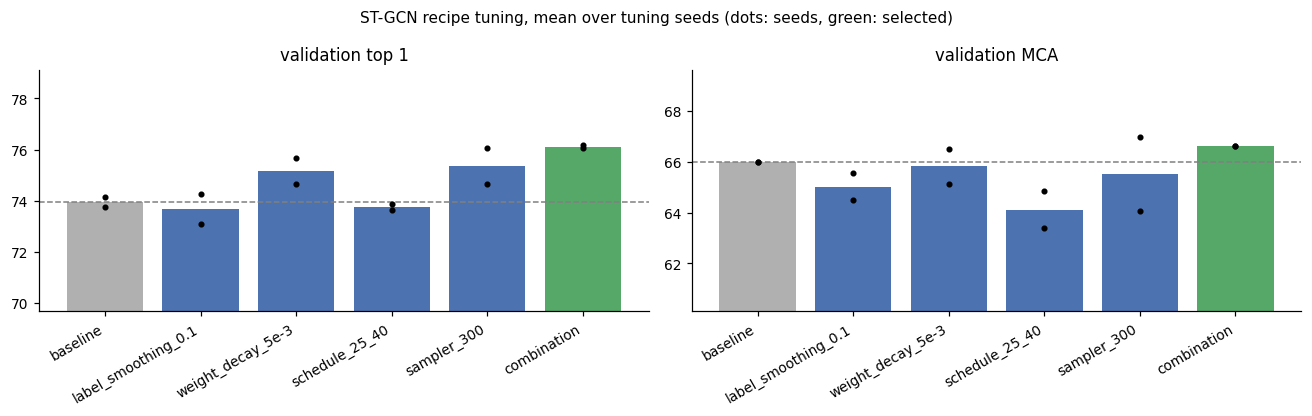

In [10]:
order = [n for n in ["baseline", *FACTORS, combo_name] if n in table.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
x = np.arange(len(order))
for ax, metric, title in zip(axes, ["val_top1", "val_mca"], ["validation top 1", "validation MCA"]):
    means = [results.loc[results["config"] == n, metric].mean() for n in order]
    colours = ["#55a868" if n == selected else "#b0b0b0" if n == "baseline" else "#4c72b0" for n in order]
    ax.bar(x, 100 * np.array(means), color=colours)
    for i, n in enumerate(order):
        ax.scatter(np.full(len(SEEDS), i), 100 * results.loc[results["config"] == n, metric], color="black", s=9, zorder=3)
    ax.axhline(100 * results.loc[results["config"] == "baseline", metric].mean(), color="grey", ls="--", lw=1)
    ax.set_xticks(x, order, rotation=30, ha="right")
    ax.set_ylim(100 * min(means) - 4, 100 * max(means) + 3)
    ax.set_title(title)
fig.suptitle("ST-GCN recipe tuning, mean over tuning seeds (dots: seeds, green: selected)", fontsize=10)
fig.tight_layout()
slog.report_matplotlib_figure("recipe comparison", "val", figure=fig, iteration=0, report_interactive=False)
plt.show()

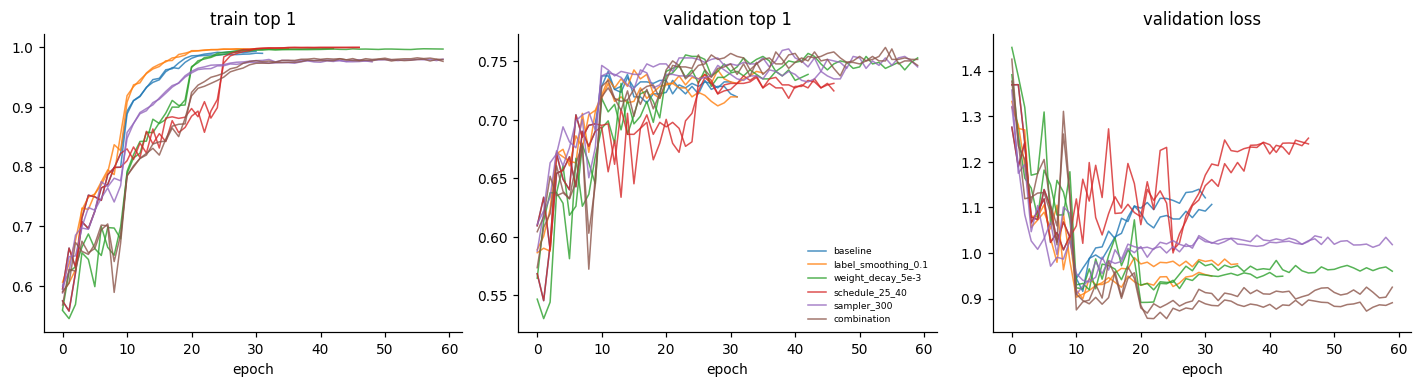

In [11]:
hist = {}
for n in order:
    curves = [pd.read_csv(f"{OUT}/stgcn_{n}_s{s}/stgcn_{n}_s{s}_history.csv") for s in SEEDS]
    hist[n] = curves

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for n, colour in zip(order, plt.cm.tab10.colors):
    for i, c in enumerate(hist[n]):
        kw = dict(color=colour, lw=1, alpha=0.8, label=n if i == 0 else None)
        axes[0].plot(c["epoch"], c["train_top1"], **kw)
        axes[1].plot(c["epoch"], c["val_top1"], **kw)
        axes[2].plot(c["epoch"], c["val_loss"], **kw)
for ax, t in zip(axes, ["train top 1", "validation top 1", "validation loss"]):
    ax.set_title(t)
    ax.set_xlabel("epoch")
axes[1].legend(frameon=False, fontsize=6)
fig.tight_layout()
slog.report_matplotlib_figure("curves by configuration", "val", figure=fig, iteration=0, report_interactive=False)
plt.show()

In [12]:
recipe = {"model": "ST-GCN", "normalisation": "body_court", "selected": selected, "changes_from_baseline": (
              {} if selected == "baseline" else (combo if selected == combo_name else FACTORS[selected])),
          **{k: v for k, v in FIXED.items() if k not in ("num_epochs", "patience")}, **selected_cfg,
          "num_epochs": FIXED["num_epochs"], "patience": FIXED["patience"],
          "tuning": {"seeds": SEEDS, "val_top1": round(float(table.loc[selected, "val top1"]), 4),
                     "baseline_val_top1": round(float(base["val top1"]), 4)}}
os.makedirs(f"{REPO}/configs", exist_ok=True)
with open(f"{REPO}/configs/stgcn_recipe.json", "w") as f:
    json.dump(recipe, f, indent=2)
task.upload_artifact("selected_recipe", artifact_object=f"{REPO}/configs/stgcn_recipe.json")
task.upload_artifact("results", artifact_object=results_path)
task.close()
recipe

{'model': 'ST-GCN',
 'normalisation': 'body_court',
 'selected': 'combination',
 'changes_from_baseline': {'weight_decay': 0.005, 'target_per_class': 300},
 'augmentation': 'advanced',
 'min_native_frames': 5,
 'batch_size': 16,
 'lr': 0.01,
 'momentum': 0.9,
 'gamma': 0.1,
 'select_metric': 'top1',
 'weight_decay': 0.005,
 'label_smoothing': 0.0,
 'schedule': 'step10',
 'target_per_class': 300,
 'num_epochs': 60,
 'patience': 20,
 'tuning': {'seeds': [11, 22],
  'val_top1': 0.7612,
  'baseline_val_top1': 0.7394}}

## Notes for the thesis

- Selection used validation only, with tuning seeds that differ from the reporting seeds.
- Validation accuracy here is optimistic by a point or two because the checkpoint is chosen on it; the same
  effect applies to every configuration, so the comparison between them is not biased.
- Which changes were tried, and which were kept, is recorded in `configs/stgcn_recipe.json`, and every run is in
  ClearML under `experiments/stgcn_recipe`.